**WARNING: this was LLM-generated and has not been fully reviewed yet.**

# Competitive Binding and Concentration Sweeps

This notebook demonstrates how to use equiconc to study competitive
binding and visualize how equilibrium shifts with changing conditions.

In [2]:
import equiconc
import numpy as np
import matplotlib.pyplot as plt

## Example 1: competitive dimers

Strand **A** can bind either **B** (forming **AB**) or **C** (forming **AC**).
We fix $[\text{A}]_0 = [\text{C}]_0 = 1\;\mu\text{M}$ and sweep
$[\text{B}]_0$ to see how the competitor displaces **C** from **A**.

- $\Delta G^\circ_{\text{AB}} = -12$ kcal/mol (stronger binder)
- $\Delta G^\circ_{\text{AC}} = -10$ kcal/mol (weaker binder)

In [ ]:
conc_A = 1e-6   # 1 uM
conc_C = 1e-6   # 1 uM
dg_AB = -12.0
dg_AC = -10.0

conc_B_range = np.logspace(-8, -4, 80)  # 10 nM to 100 uM

results = {"B0": [], "free_A": [], "AB": [], "AC": [], "free_B": [], "free_C": []}

for conc_B in conc_B_range:
    eq = (
        equiconc.System()
        .monomer("A", conc_A)
        .monomer("B", conc_B)
        .monomer("C", conc_C)
        .complex("AB", [("A", 1), ("B", 1)], dg_st=dg_AB)
        .complex("AC", [("A", 1), ("C", 1)], dg_st=dg_AC)
        .equilibrium()
    )
    results["B0"].append(conc_B)
    results["free_A"].append(eq["A"])
    results["AB"].append(eq["AB"])
    results["AC"].append(eq["AC"])
    results["free_B"].append(eq["B"])
    results["free_C"].append(eq["C"])

As $[\text{B}]_0$ increases, **AB** formation rises and **AC** is displaced.

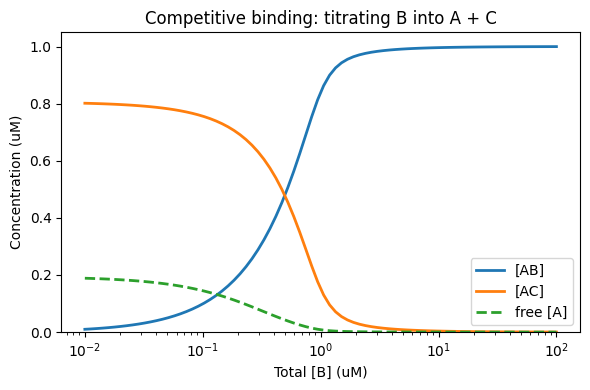

In [33]:
B0_uM = np.array(results["B0"]) * 1e6

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(B0_uM, np.array(results["AB"]) * 1e6, label="[AB]", linewidth=2)
ax.plot(B0_uM, np.array(results["AC"]) * 1e6, label="[AC]", linewidth=2)
ax.plot(B0_uM, np.array(results["free_A"]) * 1e6, label="free [A]",
        linewidth=2, linestyle="--")
ax.set_xscale("log")
ax.set_xlabel("Total [B] (uM)")
ax.set_ylabel("Concentration (uM)")
ax.set_title("Competitive binding: titrating B into A + C")
ax.legend()
ax.set_ylim(bottom=0)
fig.tight_layout()
plt.show()


Next, we fix all concentrations at 1 $\mu$M and sweep temperature
to see how the equilibrium shifts. We'll set $\Delta G^\circ$ to -15.0 at 37°C, and use a $\Delta S$ of -0.3.

In [ ]:
temperatures_C = np.linspace(10, 90, 80)

conc_all = 1e-6
dg37 = -15.0
ds = -0.3

conc_bound = np.array([
        equiconc.System(temperature_C=T)
        .monomer("A", conc_all)
        .monomer("B", conc_all)
        .complex("AB", [("A", 1), ("B", 1)], dg_st=(dg37,37), ds_st=ds)
        .equilibrium()["AB"] for T in temperatures_C])

fraction_bound = conc_bound/conc_all

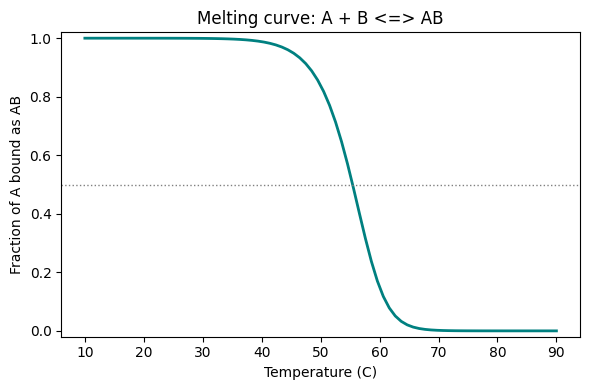

In [36]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(temperatures_C, fraction_bound, linewidth=2, color="teal")
ax.set_xlabel("Temperature (C)")
ax.set_ylabel("Fraction of A bound as AB")
ax.set_title("Melting curve: A + B <=> AB")
ax.set_ylim(-0.02, 1.02)
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
fig.tight_layout()
plt.show()